
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [1]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [7]:
class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty, pow_type="leading_zeros"):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash
        self.pow_type = pow_type        # New: type of Proof-of-Work

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce,
            "pow_type": self.pow_type # Include PoW type in hash calculation
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()

    def mine(self):
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            valid_proof = False

            if self.pow_type == "leading_zeros":
                target = '0' * self.difficulty  # target prefix
                if self.hash.startswith(target):
                    valid_proof = True
            elif self.pow_type == "numeric_threshold":
                # Convert hash (hex string) to an integer
                hash_as_int = int(self.hash, 16)
                # Define target value based on difficulty
                # Each increase in difficulty by 1 effectively aims for 4 more leading zero bits
                # So, a difficulty of `N` means the hash integer must be less than 2^(256 - N*4)
                target_value = 2**(256 - self.difficulty * 4)
                if hash_as_int < target_value:
                    valid_proof = True
            else:
                raise ValueError(f"Unsupported Proof-of-Work type: {self.pow_type}")

            if valid_proof:
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts

##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [8]:
class Blockchain:
    def __init__(self, difficulty=3, reward=10, pow_type="leading_zeros"):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.pow_type = pow_type       # Store the PoW type for the blockchain
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty,
            self.pow_type # Pass pow_type to Block
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(
            len(self.chain),
            time.time(),
            txs,
            prev.hash,
            self.difficulty,
            self.pow_type # Pass pow_type to Block
        )
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string

## 🚀 Example: Create Blockchain and Add Transactions

In [4]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 3.620569944381714 seconds
Attempts: 81582


In [5]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1777632260.3339713
 Hash        : 0000058000c23ba26ca66e2af46ed6fd8356c49ad07c92bf088996ef83505060
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 73153
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1777632261.9601066
 Hash        : 000004362ab03490e8ec171a71e0c8fce9f159374623387d7768efc5773981df
 Prev Hash   : 0000058000c23ba26ca66e2af46ed6fd8356c49ad07c92bf088996ef83505060
 Difficulty  : 5
 Nonce       : 81582
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

## Mining Time Comparison: Leading Zeros vs. Numeric Threshold PoW

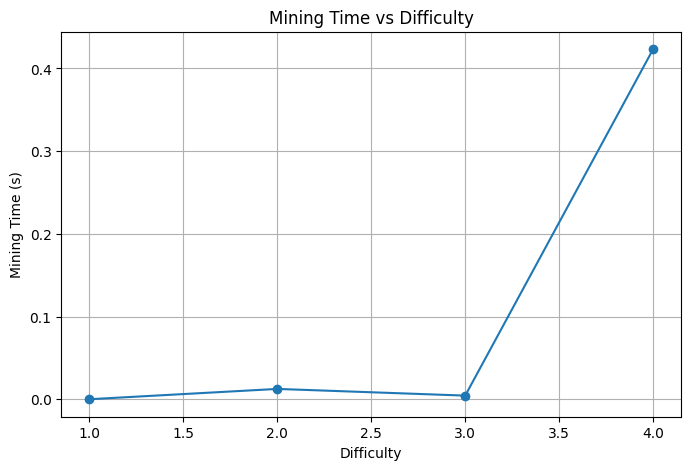

In [6]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


Mining with Leading Zeros PoW...
  Difficulty 1: 0.0003s, 20 attempts
  Difficulty 2: 0.0035s, 240 attempts
  Difficulty 3: 0.0009s, 78 attempts
  Difficulty 4: 0.7776s, 69451 attempts
  Difficulty 5: 14.1145s, 1140890 attempts

Mining with Numeric Threshold PoW...
  Difficulty 1: 0.0001s, 3 attempts
  Difficulty 2: 0.0017s, 117 attempts
  Difficulty 3: 0.0170s, 1456 attempts
  Difficulty 4: 0.3103s, 26861 attempts
  Difficulty 5: 13.5117s, 963300 attempts


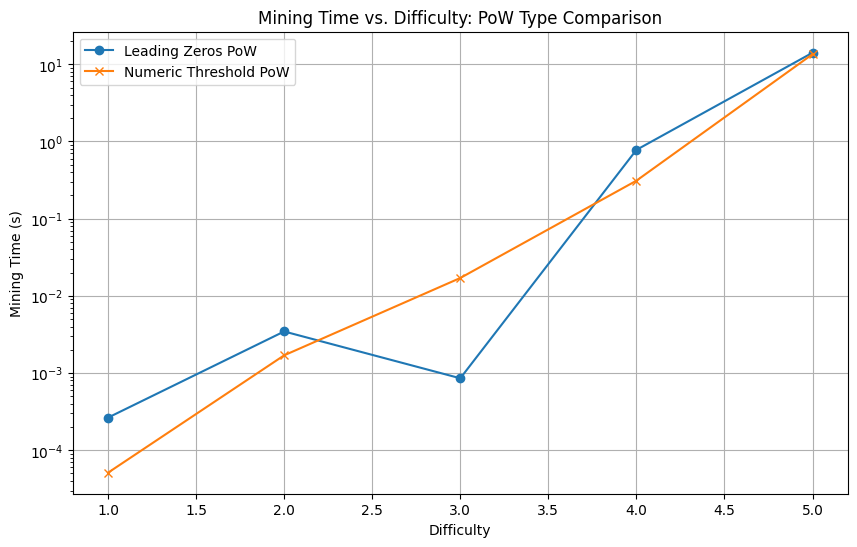

In [9]:
difficulties = [1, 2, 3, 4, 5] # Test difficulty levels for comparison

# --- Leading Zeros PoW ---
leading_zeros_times = []
print("Mining with Leading Zeros PoW...")
for d in difficulties:
    bc_lz = Blockchain(difficulty=d, reward=1, pow_type="leading_zeros")
    bc_lz.add_transaction("A", "B", 1)
    t, att = bc_lz.mine_pending("MinerLZ")
    leading_zeros_times.append(t)
    print(f"  Difficulty {d}: {t:.4f}s, {att} attempts")

# --- Numeric Threshold PoW ---
numeric_threshold_times = []
print("\nMining with Numeric Threshold PoW...")
for d in difficulties:
    bc_nt = Blockchain(difficulty=d, reward=1, pow_type="numeric_threshold")
    bc_nt.add_transaction("C", "D", 1)
    t, att = bc_nt.mine_pending("MinerNT")
    numeric_threshold_times.append(t)
    print(f"  Difficulty {d}: {t:.4f}s, {att} attempts")

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(difficulties, leading_zeros_times, marker='o', label='Leading Zeros PoW')
plt.plot(difficulties, numeric_threshold_times, marker='x', label='Numeric Threshold PoW')
plt.xlabel('Difficulty')
plt.ylabel('Mining Time (s)')
plt.title('Mining Time vs. Difficulty: PoW Type Comparison')
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True)
plt.legend()
plt.show()

#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.







